In this notebook, we will explore how to use neural networks for non-linear classification. In particular, we will deal with binary classification, where each data point can belong to either one of two classes.

## Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# set random seed for reproducibility
np.random.seed(42)

In [3]:
from nnfs.layers import Dense
from nnfs.model import Sequential
from nnfs.losses import BCE, MSE
from nnfs.optimizers import SGD
from nnfs.activations import Sigmoid

from nnfs.datasets.data_generators import generate_two_moons, generate_concentric_circles

## Step function

The simplest example of non-linearity is the step function, represented below. For all $ x<0 $, $y=0$, and for all $x>=0$, $y=1$.

### Data generation

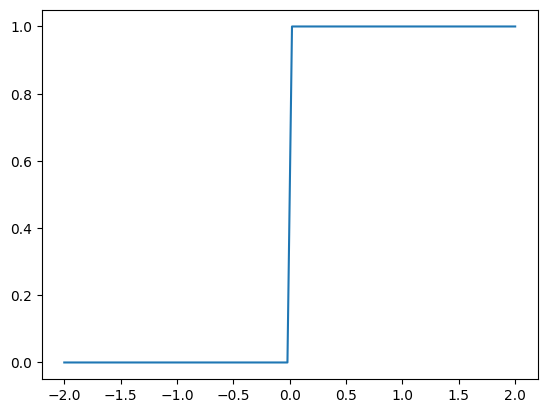

In [4]:
# generate data
X_data = np.linspace(-2, 2, 100).reshape(-1,1)
y_true = (X_data > 0).astype(float)  # label 0 if X<0, 1 if X>=0

# plot data
plt.plot(X_data, y_true)
None

### Linear approximation (attempt)

Let us now try to fit this function using a linear regression model as we did in the [previous notebook](../1_linear_regression).

Model layers:
    * Dense_0  | Dimensions: 1 x 1 | Parameters: 2
    --------------------
    Total parameters: 2

Epoch 1 - Loss: 0.30259486986905615
Epoch 50 - Loss: 0.09563704975236138
Epoch 100 - Loss: 0.06687829264201897
Epoch 150 - Loss: 0.06306437821071381
Epoch 200 - Loss: 0.06255858232388718
Epoch 250 - Loss: 0.06249150413584806
Epoch 300 - Loss: 0.06248260827142039
Epoch 350 - Loss: 0.06248142850678685
Epoch 400 - Loss: 0.06248127204698571
Epoch 450 - Loss: 0.06248125129736021
Epoch 500 - Loss: 0.06248124854555434


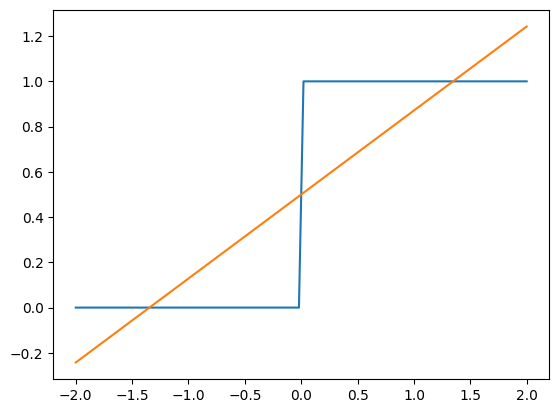

In [5]:
list_layers = [Dense(1, 1)]
loss = MSE()
optimizer = SGD()
model = Sequential(list_layers, loss, optimizer)
model.summary()
print()

history = model.fit(X_data, y_true, N_epochs=500)
y_pred = model.forward(X_data)
plt.plot(X_data, y_true)
plt.plot(X_data, y_pred)
None

Not surprisingly, we cannot really fit the step function with a linear model. 

*\[Wrong assumption\]*: Let us simply increase the complexity of the model, that ought to solve the issue!

Model layers:
    * Dense_0  | Dimensions: 1 x 16 | Parameters: 32
    * Dense_1  | Dimensions: 16 x 8 | Parameters: 136
    * Dense_2  | Dimensions: 8 x 1 | Parameters: 9
    --------------------
    Total parameters: 177

Epoch 1 - Loss: 48.64374025147111
Epoch 50 - Loss: 0.19329894748326615
Epoch 100 - Loss: 0.13414610571246494
Epoch 150 - Loss: 0.10127296740111602
Epoch 200 - Loss: 0.08323945154674896
Epoch 250 - Loss: 0.07348004430036026
Epoch 300 - Loss: 0.06826237342115811
Epoch 350 - Loss: 0.06550087554435242
Epoch 400 - Loss: 0.06405095252766642
Epoch 450 - Loss: 0.06329431985971024
Epoch 500 - Loss: 0.06290128949214305


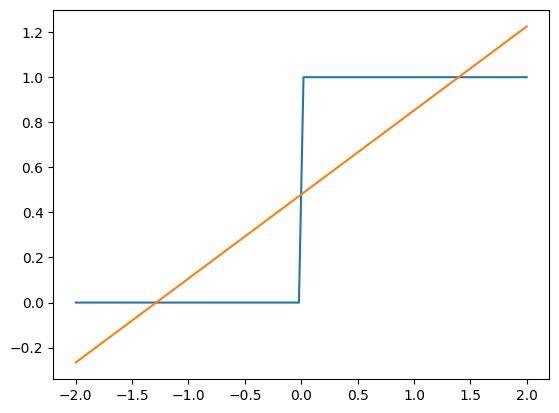

In [6]:
list_layers = [Dense(1, 16),
               Dense(16, 8),
               Dense(8, 1)]
loss = MSE()
optimizer = SGD(lr=0.001)
model = Sequential(list_layers, loss, optimizer)
model.summary()
print()

history = model.fit(X_data, y_true, N_epochs=500)
y_pred = model.forward(X_data)
plt.plot(X_data, y_true)
plt.plot(X_data, y_pred)
None

Turns out, no matter how many layers a linear neural network model has, it can always be expressed as a single-layer model (in other words, they are functionally equivalent). This means that in order to fit nonlinear relationships in data, we need an additional component: a nonlinear activation function.

The [sigmoid](../../math_activations/#sigmoid) activation function does not have trainable parameters, and like other activation functions, it simply transforms its inputs. By introducing nonlinearity, it dramatically expands what the network can represent.

### Model specification

In [7]:
# define the model
list_layers = [Dense(1, 1),
               Sigmoid()]
loss = BCE()
optimizer = SGD()
model = Sequential(list_layers, loss, optimizer)
model.summary()

Model layers:
    * Dense_0  | Dimensions: 1 x 1 | Parameters: 2
    * Sigmoid_1 
    --------------------
    Total parameters: 2


### Training

In [8]:
# fit the model to the data
history = model.fit(X_data, y_true, N_epochs=5000)

Epoch 1 - Loss: 0.3823615161958774
Epoch 500 - Loss: 0.04787079263408062
Epoch 1000 - Loss: 0.037889991946775683
Epoch 1500 - Loss: 0.03303472830453189
Epoch 2000 - Loss: 0.029963671988919888
Epoch 2500 - Loss: 0.02777372511058216
Epoch 3000 - Loss: 0.026099447019208865
Epoch 3500 - Loss: 0.024759539167840447
Epoch 4000 - Loss: 0.023651950415279385
Epoch 4500 - Loss: 0.022714029747108677
Epoch 5000 - Loss: 0.02190478953897583


### Evaluation

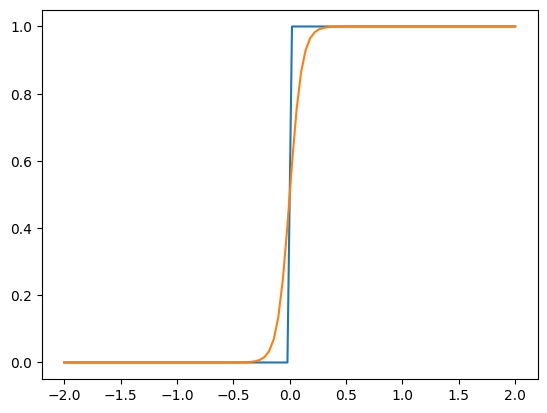

In [9]:
# produce predictions
y_pred = model.forward(X_data)

# compare predicted and target values
plt.plot(X_data, y_true)
plt.plot(X_data, y_pred)
None

Although not perfect, this model seems to be able to reproduce the step function well enough. To improve the fitting further, we could keep training the model to make it arbitrarily close to the target.

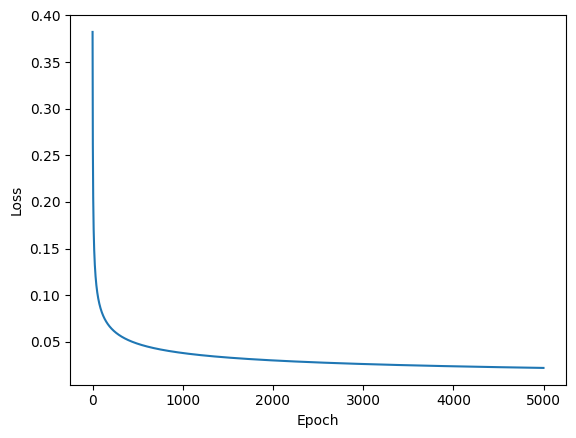

In [10]:
# get loss values from history
loss = history["loss"]

# plot
plt.plot(loss)
plt.xlabel("Epoch")
plt.ylabel("Loss")
None

## XOR gate

Another classic non-linear problem is the XOR gate (eXclusive OR). This function returns 1 when two bits are different (0,1 and 1,0), and 0 for other combinations (0,0 and 1,1).

<a id="data-generation_1"></a>
### Data generation

In [11]:
X_data = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

y_true = np.array([0, 1, 1, 0]).reshape(-1, 1)

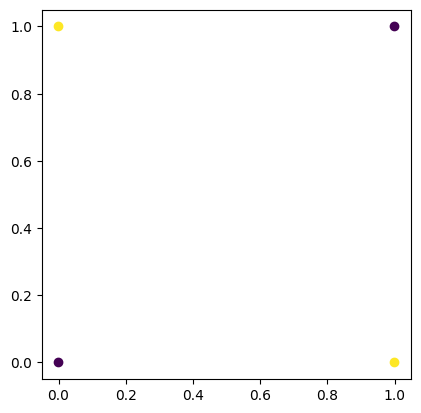

In [12]:
plt.scatter(X_data[:, 0], X_data[:, 1], c=y_true)
plt.axis('square')
None

<a id="model-specification_1"></a>
### Model specification

Since, by design, we are dealing with binary labels, and the model outputs lay in the range $(0,1)$, we can use an appropriate loss function such as binary cross entropy (BCE).

In [13]:
# define the model
list_layers = [Dense(2, 2), Sigmoid(),
               Dense(2, 1), Sigmoid()]
loss = BCE()
optimizer = SGD()
model = Sequential(list_layers, loss, optimizer)
model.summary()

Model layers:
    * Dense_0  | Dimensions: 2 x 2 | Parameters: 6
    * Sigmoid_1 
    * Dense_2  | Dimensions: 2 x 1 | Parameters: 3
    * Sigmoid_3 
    --------------------
    Total parameters: 9


<a id="training_1"></a>
### Training

In [14]:
# fit the model to the data
history = model.fit(X_data, y_true, 50000, debug_flag=True)

Epoch 1 - Loss: 0.7362699897385817
Epoch 5000 - Loss: 0.6607652017325525
Epoch 10000 - Loss: 0.42214241197745583
Epoch 15000 - Loss: 0.06917006744475097
Epoch 20000 - Loss: 0.030260066176412304
Epoch 25000 - Loss: 0.018966925063784633
Epoch 30000 - Loss: 0.013721269018027787
Epoch 35000 - Loss: 0.010715857695822513
Epoch 40000 - Loss: 0.00877566458982567
Epoch 45000 - Loss: 0.007422618455075263
Epoch 50000 - Loss: 0.00642661522065401


<a id="evaluation_1"></a>
### Evaluation

In [15]:
# produce predictions
y_pred = model.forward(X_data)

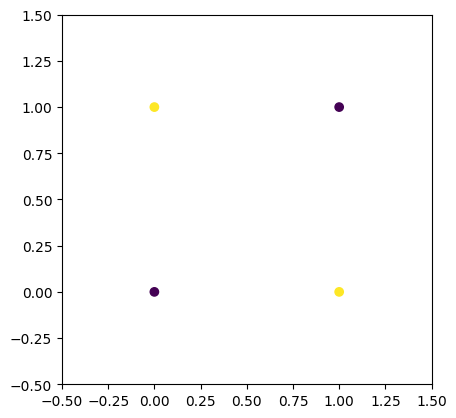

In [16]:
# graph predictions
plt.scatter(X_data[:, 0], X_data[:, 1], c=y_pred)
plt.axis('square')
plt.xlim([-0.5, 1.5])
plt.ylim([-0.5, 1.5])
ax = plt.gca()  
None

Given that we are classifying 2D coordinates, we can also graph the decision boundary of our model. In other words, which areas are considered part of either label, 0 and 1?

In [17]:
def plot_decision_boundary(title, form='square', s=100):
    # create a grid to evaluate the model
    xmin, xmax = ax.get_xlim()
    ymin, ymax = ax.get_ylim()
    
    xx, yy = np.meshgrid(np.linspace(xmin, xmax, 200),
                         np.linspace(ymin, ymax, 200))
    grid = np.c_[xx.ravel(), yy.ravel()]

    # evaluate the model on the grid
    z = model.forward(grid)
    z = z.reshape(xx.shape)

    # plot model predictions
    y_pred = model.forward(X_data)
    plt.scatter(X_data[:,0], X_data[:,1], c=y_pred, s=s, edgecolor='k', cmap='coolwarm')
 
    # plot decision boundary
    plt.contourf(xx, yy, z, alpha=0.5, cmap='coolwarm')
    plt.axis(form)
    plt.xlabel('x1')
    plt.ylabel('x2')
    plt.title(title)
    plt.show()

Notice how the decision boundary maximizes confidence of the "correct" predictions by drawing boundaries in the mid-points between our reference coordinates.

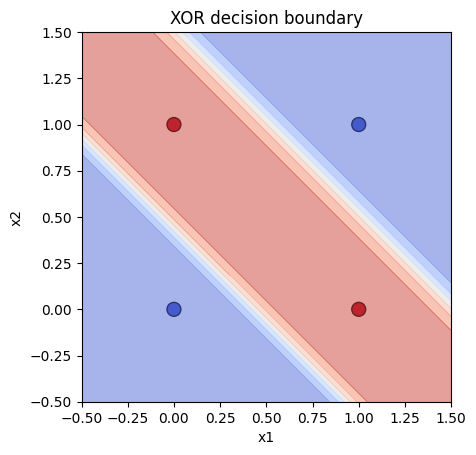

In [18]:
plot_decision_boundary('XOR decision boundary')

## XOR gate (minimal)

Are two sigmoid transformation layers required? Do we have to use binary cross entropy for binary classification? Technically, no. As long as we have at least one non-linear transformation, the model should be able to learn the XOR gate. Removing the last activation function means that the output of the model is no longer a constrained to the (0,1) range. Consequently, we should choose another loss function, such as the mean squared error (MSE).

Notice how, although the model **works** for our classification task, what it *has learned* differs greatly.

Model layers:
    * Dense_0  | Dimensions: 2 x 2 | Parameters: 6
    * Sigmoid_1 
    * Dense_2  | Dimensions: 2 x 1 | Parameters: 3
    --------------------
    Total parameters: 9

Epoch 1 - Loss: 0.25967245636217445
Epoch 5000 - Loss: 0.2403169406315312
Epoch 10000 - Loss: 0.19937309854112634
Epoch 15000 - Loss: 0.08849515329961945
Epoch 20000 - Loss: 0.003590030225816379
Epoch 25000 - Loss: 2.493979751978473e-05
Epoch 30000 - Loss: 1.348535977825122e-07
Epoch 35000 - Loss: 7.150180508220072e-10
Epoch 40000 - Loss: 3.785720068257312e-12
Epoch 45000 - Loss: 2.0041703759017526e-14
Epoch 50000 - Loss: 1.0610051563484679e-16


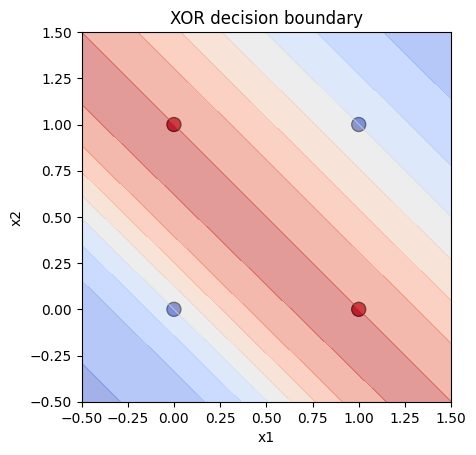

In [19]:
list_layers = [Dense(2, 2), Sigmoid(),
               Dense(2, 1)]
loss = MSE()
optimizer = SGD()
model = Sequential(list_layers, loss, optimizer)
model.summary()
print()

history = model.fit(X_data, y_true, 50000, debug_flag=True)

plot_decision_boundary('XOR decision boundary')

## Two moons

Here is a more exciting data modelling exercise. The two moons dataset requires the model to draw a sinusoidal line to cleanly separate the two groups. A few data points, however, intersect into the other moon!

<a id="data-generation_2"></a>
### Data generation

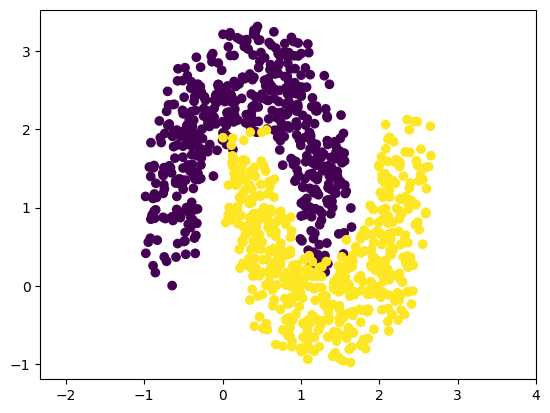

In [36]:
X_data, y_true = generate_two_moons(500)

plt.scatter(X_data[:,0], X_data[:,1], c=y_true)
plt.axis('equal')
None

<a id="model-specification_2"></a>
### Model specification

In [21]:
# define the model
list_layers = [Dense(2, 8), Sigmoid(),
               Dense(8, 1), Sigmoid()]
loss = BCE()
optimizer = SGD()
model = Sequential(list_layers, loss, optimizer)
model.summary()

Model layers:
    * Dense_0  | Dimensions: 2 x 8 | Parameters: 24
    * Sigmoid_1 
    * Dense_2  | Dimensions: 8 x 1 | Parameters: 9
    * Sigmoid_3 
    --------------------
    Total parameters: 33


<a id="training_2"></a>
### Training

In [22]:
# fit the model to the data
history = model.fit(X_data, y_true, 50000, debug_flag=True)

Epoch 1 - Loss: 6.59031920012334
Epoch 5000 - Loss: 0.04139911751220892
Epoch 10000 - Loss: 0.03600506805962694
Epoch 15000 - Loss: 0.03601905890975575
Epoch 20000 - Loss: 0.03596743073288747
Epoch 25000 - Loss: 0.035930805095302214
Epoch 30000 - Loss: 0.03583331984824449
Epoch 35000 - Loss: 0.03555784651858995
Epoch 40000 - Loss: 0.035359613124004166
Epoch 45000 - Loss: 0.03523059425885485
Epoch 50000 - Loss: 0.035130903790875634


<a id="evaluation_2"></a>
### Evaluation

In [23]:
# produce predictions
y_pred = model.forward(X_data)

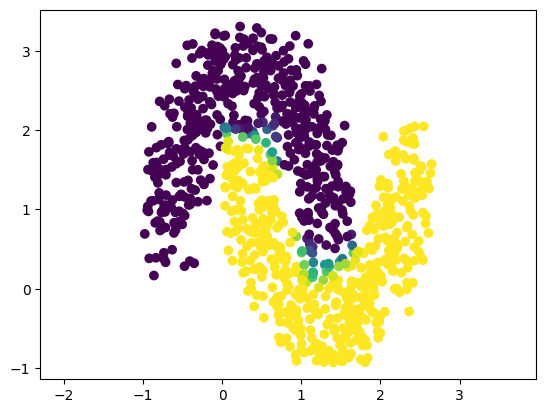

In [24]:
# graph predictions
ax = plt.scatter(X_data[:, 0], X_data[:, 1], c=y_pred)
plt.axis('equal')
ax = plt.gca()

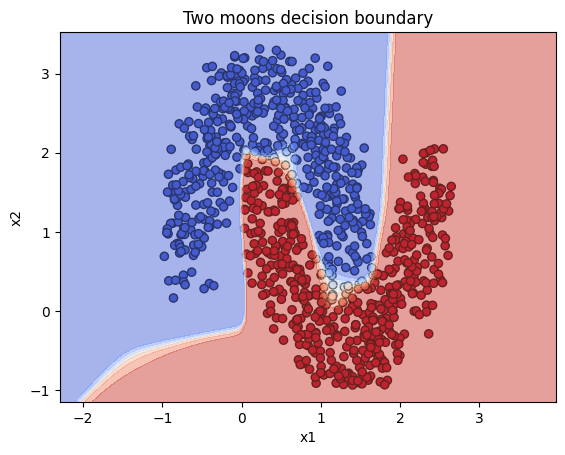

In [25]:
plot_decision_boundary('Two moons decision boundary', 'equal', s=35)

Notice how the classification confidence is lower for the more *ambiguous* regions, where data points of the two sets intersect.

## Concentric circles

This dataset requires the model to learn several concentric circles for optimal classification.

<a id="data-generation_3"></a>
### Data generation

In [26]:
X_data, y_true = generate_concentric_circles(500, 3, binary=True)

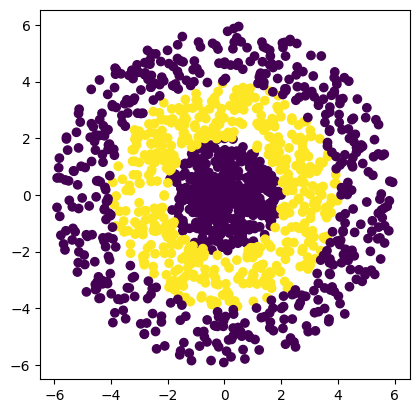

In [34]:
plt.scatter(X_data[:,0], X_data[:,1], c=y_true)
plt.axis('square')
None

<a id="model-specification_3"></a>
### Model specification

In [28]:
# define the model
list_layers = [Dense(2, 12), Sigmoid(),
               Dense(12, 2), Sigmoid(),
               Dense(2, 1), Sigmoid()]
loss = BCE()
optimizer = SGD(0.01)
model = Sequential(list_layers, loss, optimizer)
model.summary()

Model layers:
    * Dense_0  | Dimensions: 2 x 12 | Parameters: 36
    * Sigmoid_1 
    * Dense_2  | Dimensions: 12 x 2 | Parameters: 26
    * Sigmoid_3 
    * Dense_4  | Dimensions: 2 x 1 | Parameters: 3
    * Sigmoid_5 
    --------------------
    Total parameters: 65


<a id="training_3"></a>
### Training

In [29]:
# fit the model to the data
history = model.fit(X_data, y_true, 50000, debug_flag=True)

Epoch 1 - Loss: 3.271527823048571
Epoch 5000 - Loss: 0.7197162507583815
Epoch 10000 - Loss: 0.7509054453905305
Epoch 15000 - Loss: 0.7613654264082852
Epoch 20000 - Loss: 0.7838048873409944
Epoch 25000 - Loss: 0.7804344130606405
Epoch 30000 - Loss: 0.4237352152825453
Epoch 35000 - Loss: 0.13003233234596556
Epoch 40000 - Loss: 0.14460894873074961
Epoch 45000 - Loss: 0.09530319848440816
Epoch 50000 - Loss: 0.16331279450802594


<a id="evaluation_3"></a>
### Evaluation

In [30]:
# produce predictions
y_pred = model.forward(X_data)

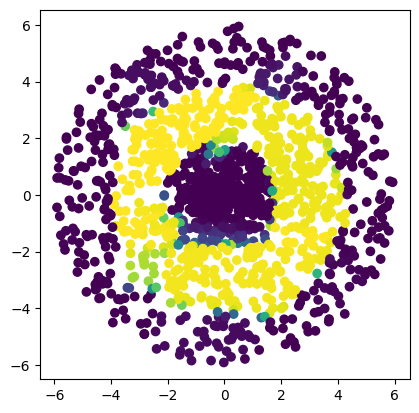

In [35]:
# graph predictions
plt.scatter(X_data[:, 0], X_data[:, 1], c=y_pred)
plt.axis('square')
ax = plt.gca()

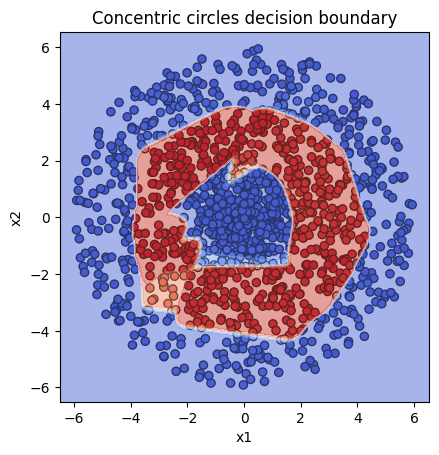

In [32]:
plot_decision_boundary('Concentric circles decision boundary', s=35)